## Validation of `panodisplay_proton.C` Optical Model Tables

This notebook compares the optical model tables hardcoded in `simulation-tools/panodisplay_proton.C` against the physical curves in `optical_model_data_pack_alt10km_zn30.json`:

1. **PMMA Refractive Index Table**: `kRefractiveIndexGrid` (51 points from 1.0 to 6.0 eV in steps of 0.1 eV) vs `data_pack["refractive_index"]`.
2. **Cherenkov Detection Spectrum & Inverse CDF**: `kInvCDFEnergy` (101 points from 1.305 eV to 3.647 eV) vs `data_pack["full_pde"]` (Cherenkov spectrum convolved with atmospheric transmission at altitude 10 km, zenith angle 30°, PMMA transmission, and SiPM PDE).


In [1]:
%matplotlib inline
import sys
sys.path.append("../..")

import json
import os
import numpy as np
import matplotlib.pyplot as plt

from pypanodecoder import optical_model


In [2]:
# Explicitly load the alt=10km zn=30deg optical model data pack JSON file
json_path = os.path.join(os.path.dirname(optical_model.__file__), "resources", "optical_model_data_pack_alt10km_zn30.json")
with open(json_path, "r") as f:
    data_pack = json.load(f)

print(f"Loaded optical model data pack from: {json_path}")
print(f"Optical parameters: D = {data_pack['optical_model']['D']} cm, F = {data_pack['optical_model']['F']} cm")


Loaded optical model data pack from: /grid_mnt/vol_home/llr/glast/fegan/GitHub/PANOSETI-High-Energy-Analysis-Pipeline/pypanodecoder/examples/../../pypanodecoder/resources/optical_model_data_pack_alt10km_zn30.json
Optical parameters: D = 46.09 cm, F = 60.78 cm


In [3]:
# Hardcoded tables from simulation-tools/panodisplay_proton.C

kRefractiveIndexEMin = 1.00
kRefractiveIndexEMax = 6.00
kNumRefractiveIndexGrid = 51
kRefractiveIndexGrid = np.array([
    1.466383, 1.467147, 1.467994, 1.468914, 1.469911, 1.470988, 1.472144, 1.473380,
    1.474700, 1.476102, 1.477590, 1.479164, 1.480827, 1.482580, 1.484426, 1.486365,
    1.488401, 1.490535, 1.492770, 1.495111, 1.497558, 1.500117, 1.502792, 1.505586,
    1.508467, 1.511482, 1.514626, 1.517903, 1.521315, 1.524868, 1.528565, 1.532412,
    1.536416, 1.540581, 1.544915, 1.549424, 1.554115, 1.558997, 1.564076, 1.569360,
    1.574865, 1.580594, 1.586560, 1.592774, 1.599251, 1.606005, 1.613040, 1.620392,
    1.628056, 1.636061, 1.644431
])

kNumUGrid = 201
kInvCDFEnergy = np.array([
    1.305097, 1.405120, 1.449981, 1.486680, 1.519204,
    1.547630, 1.573380, 1.596913, 1.619006, 1.642698,
    1.661821, 1.680094, 1.697955, 1.715681, 1.732686,
    1.748250, 1.763344, 1.778084, 1.792426, 1.806646,
    1.819888, 1.832719, 1.845235, 1.857458, 1.869423,
    1.881172, 1.892775, 1.904193, 1.915422, 1.926377,
    1.937024, 1.947466, 1.957723, 1.967757, 1.977610,
    1.987181, 1.996568, 2.005831, 2.014978, 2.024016,
    2.032950, 2.041785, 2.050527, 2.059185, 2.067772,
    2.076315, 2.084811, 2.093248, 2.101612, 2.109908,
    2.117991, 2.125959, 2.133850, 2.141674, 2.149439,
    2.157156, 2.164818, 2.172418, 2.179967, 2.187447,
    2.194839, 2.202173, 2.209452, 2.216678, 2.223854,
    2.230979, 2.238057, 2.245086, 2.252068, 2.259010,
    2.265911, 2.272772, 2.279595, 2.286380, 2.293128,
    2.299846, 2.306532, 2.313189, 2.319814, 2.326411,
    2.332977, 2.339517, 2.346026, 2.352510, 2.358970,
    2.365408, 2.371824, 2.378220, 2.384596, 2.390950,
    2.397286, 2.403601, 2.409896, 2.416173, 2.422430,
    2.428669, 2.434889, 2.441093, 2.447280, 2.453458,
    2.459628, 2.465787, 2.471937, 2.478078, 2.484211,
    2.490338, 2.496462, 2.502582, 2.508699, 2.514813,
    2.520924, 2.527031, 2.533136, 2.539237, 2.545336,
    2.551432, 2.557525, 2.563617, 2.569710, 2.575803,
    2.581896, 2.587990, 2.594085, 2.600179, 2.606274,
    2.612370, 2.618466, 2.624564, 2.630663, 2.636764,
    2.642866, 2.648969, 2.655074, 2.661182, 2.667294,
    2.673412, 2.679535, 2.685663, 2.691795, 2.697935,
    2.704084, 2.710244, 2.716415, 2.722597, 2.728793,
    2.735005, 2.741233, 2.747478, 2.753740, 2.760019,
    2.766316, 2.772630, 2.778961, 2.785310, 2.791677,
    2.798063, 2.804472, 2.810905, 2.817363, 2.823845,
    2.830353, 2.836886, 2.843450, 2.850046, 2.856676,
    2.863339, 2.870040, 2.876786, 2.883577, 2.890412,
    2.897305, 2.904265, 2.911298, 2.918407, 2.925599,
    2.932890, 2.940294, 2.947809, 2.955475, 2.963291,
    2.971274, 2.979451, 2.987828, 2.996470, 3.005357,
    3.014575, 3.024096, 3.034036, 3.044433, 3.055327,
    3.066807, 3.078999, 3.092001, 3.106080, 3.121486,
    3.138554, 3.158061, 3.181192, 3.210602, 3.254194,
    3.646594
])


In [4]:
def cxx_get_refractive_index(energy_eV):
    if energy_eV <= kRefractiveIndexEMin:
        return kRefractiveIndexGrid[0]
    if energy_eV >= kRefractiveIndexEMax:
        return kRefractiveIndexGrid[-1]
    frac_idx = (energy_eV - kRefractiveIndexEMin) / (kRefractiveIndexEMax - kRefractiveIndexEMin) * (kNumRefractiveIndexGrid - 1)
    idx = int(np.floor(frac_idx))
    frac = frac_idx - idx
    return kRefractiveIndexGrid[idx] * (1.0 - frac) + kRefractiveIndexGrid[idx + 1] * frac

cxx_get_refractive_index_vec = np.vectorize(cxx_get_refractive_index)

def cxx_sample_photon_energy(u):
    idx_d = u * (kNumUGrid - 1)
    idx = np.clip(np.floor(idx_d).astype(int), 0, kNumUGrid - 2)
    frac = idx_d - idx
    return kInvCDFEnergy[idx] * (1.0 - frac) + kInvCDFEnergy[idx + 1] * frac


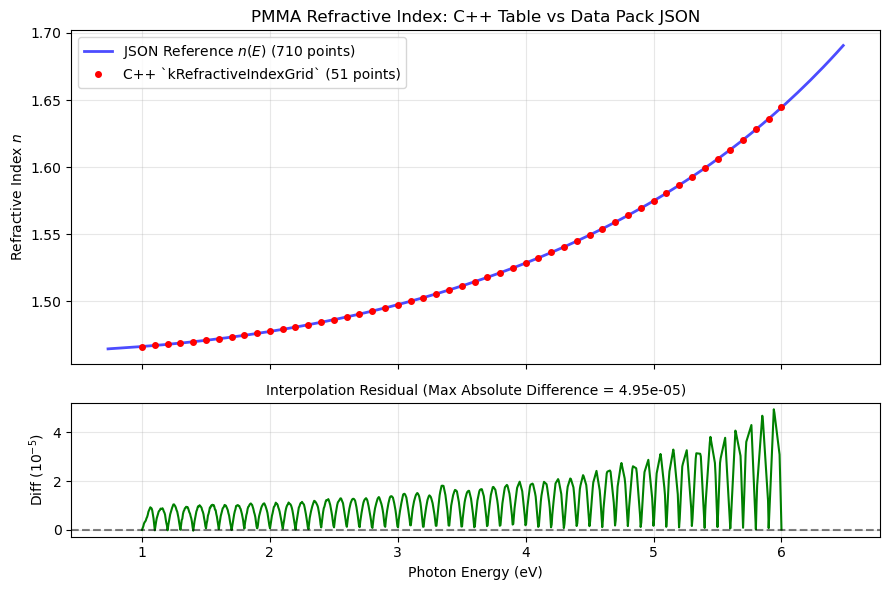

In [5]:
# 1. PMMA Refractive Index Comparison
ri_ev = np.array(data_pack["refractive_index"]["ev"])
ri_n = np.array(data_pack["refractive_index"]["n"])
sort_ri = np.argsort(ri_ev)
ri_ev = ri_ev[sort_ri]
ri_n = ri_n[sort_ri]

ev_eval = np.linspace(1.0, 6.0, 1000)
n_ref_eval = np.interp(ev_eval, ri_ev, ri_n)
n_cxx_eval = cxx_get_refractive_index_vec(ev_eval)

grid_e = np.linspace(kRefractiveIndexEMin, kRefractiveIndexEMax, kNumRefractiveIndexGrid)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True, gridspec_kw={'height_ratios': [2.5, 1]})

ax1.plot(ri_ev, ri_n, 'b-', label='JSON Reference $n(E)$ (710 points)', alpha=0.7, lw=2)
ax1.plot(grid_e, kRefractiveIndexGrid, 'ro', label=f'C++ `kRefractiveIndexGrid` ({kNumRefractiveIndexGrid} points)', markersize=4)
ax1.set_ylabel('Refractive Index $n$')
ax1.set_title('PMMA Refractive Index: C++ Table vs Data Pack JSON')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

diff = n_cxx_eval - n_ref_eval
ax2.plot(ev_eval, diff * 1e5, 'g-', lw=1.5)
ax2.axhline(0, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel('Photon Energy (eV)')
ax2.set_ylabel('Diff ($10^{-5}$)')
ax2.grid(True, alpha=0.3)
max_err = np.max(np.abs(diff))
ax2.set_title(f'Interpolation Residual (Max Absolute Difference = {max_err:.2e})', fontsize=10)

plt.tight_layout()
plt.show()


<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:38: SyntaxWarning: invalid escape sequence '\i'
<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:38: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_1493543/2882323033.py:27: SyntaxWarning: invalid escape sequence '\c'
  ax1.set_title('Cherenkov Detection Spectrum (Alt 10 km, $z_n = 30^\circ$)')
/tmp/ipykernel_1493543/2882323033.py:38: SyntaxWarning: invalid escape sequence '\i'
  ax2.set_xlabel('Uniform Random Variable $u \in [0, 1]$')


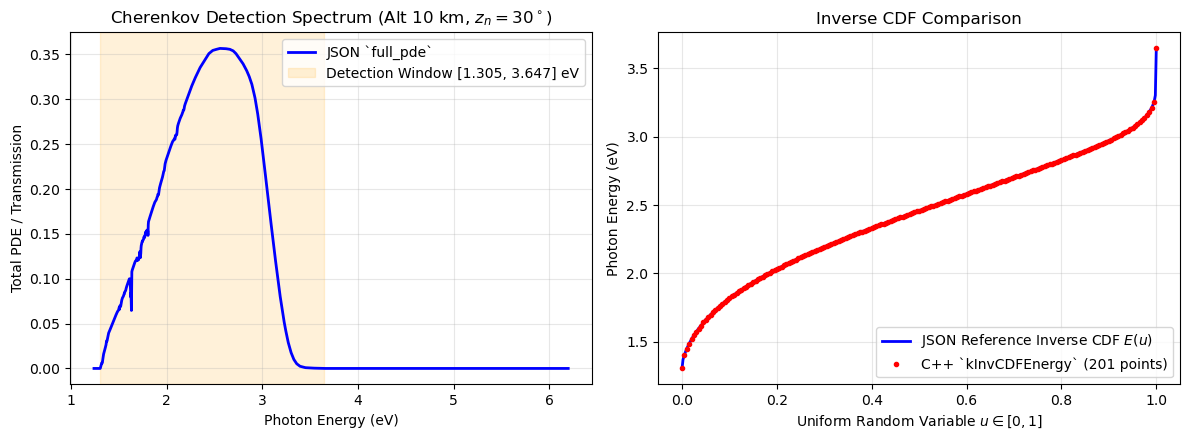

In [6]:
# 2. Cherenkov Full PDE and Inverse CDF Comparison
fp_ev = np.array(data_pack["full_pde"]["ev"])
fp_eff = np.array(data_pack["full_pde"]["eff"])
sort_fp = np.argsort(fp_ev)
fp_ev = fp_ev[sort_fp]
fp_eff = fp_eff[sort_fp]

# Trimmed non-zero window
nonzero_idx = np.where(fp_eff > 0)[0]
start_idx = max(0, nonzero_idx[0] - 1)
end_idx = min(len(fp_ev), nonzero_idx[-1] + 2)
trimmed_ev = fp_ev[start_idx:end_idx]
trimmed_eff = fp_eff[start_idx:end_idx]

cum_eff = np.concatenate(([0], np.cumsum(0.5 * (trimmed_eff[:-1] + trimmed_eff[1:]) * np.diff(trimmed_ev))))
cdf_ref = cum_eff / cum_eff[-1]

u_grid = np.linspace(0.0, 1.0, kNumUGrid)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: Full PDE Spectrum
ax1.plot(fp_ev, fp_eff, 'b-', lw=2, label='JSON `full_pde`')
ax1.axvspan(kInvCDFEnergy[0], kInvCDFEnergy[-1], color='orange', alpha=0.15, label=f'Detection Window [{kInvCDFEnergy[0]:.3f}, {kInvCDFEnergy[-1]:.3f}] eV')
ax1.set_xlabel('Photon Energy (eV)')
ax1.set_ylabel('Total PDE / Transmission')
ax1.set_title('Cherenkov Detection Spectrum (Alt 10 km, $z_n = 30^\circ$)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Right: Inverse CDF E(u)
u_eval = np.linspace(0.0, 1.0, 500)
e_inv_ref_eval = np.interp(u_eval, cdf_ref, trimmed_ev)
e_inv_cxx_eval = cxx_sample_photon_energy(u_eval)

ax2.plot(u_eval, e_inv_ref_eval, 'b-', lw=2, label='JSON Reference Inverse CDF $E(u)$')
ax2.plot(u_grid, kInvCDFEnergy, 'ro', markersize=3, label=f'C++ `kInvCDFEnergy` ({kNumUGrid} points)')
ax2.set_xlabel('Uniform Random Variable $u \in [0, 1]$')
ax2.set_ylabel('Photon Energy (eV)')
ax2.set_title('Inverse CDF Comparison')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1493543/4084907138.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_factor = np.trapz(trimmed_eff, trimmed_ev)


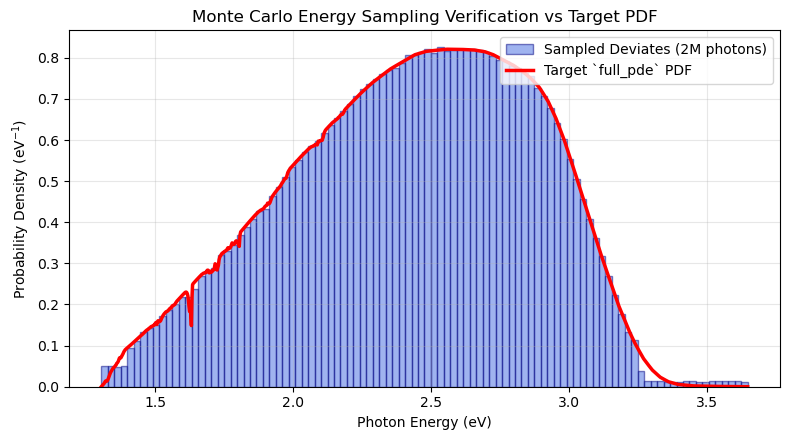

In [7]:
# 3. Monte Carlo Energy Sampling Verification
np.random.seed(42)
u_samples = np.random.uniform(0.0, 1.0, 2000000)
e_samples = cxx_sample_photon_energy(u_samples)

plt.figure(figsize=(8, 4.5))
plt.hist(e_samples, bins=100, density=True, alpha=0.5, color='royalblue', edgecolor='navy', label='Sampled Deviates (2M photons)')

norm_factor = np.trapz(trimmed_eff, trimmed_ev)
plt.plot(trimmed_ev, trimmed_eff / norm_factor, 'r-', lw=2.5, label='Target `full_pde` PDF')

plt.xlabel('Photon Energy (eV)')
plt.ylabel('Probability Density (eV$^{-1}$)')
plt.title('Monte Carlo Energy Sampling Verification vs Target PDF')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
